# 05 - Residuals Analysis  


Version 1.00  
Created 05.05.26  
Loads predictions from all models and generates residual diagnostics.

## Imports

In [1]:
# Imports & Config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append(r'Q:\scripts\projects\ts-model-framework')
import config

print(f"Models path: {config.MODELS_PATH}")
print(f"Experiment: {config.EXPERIMENT}")

Models path: Q:\scripts\projects\ts-model-framework\models
Experiment: favorita


---
## S1 - Load All Predictions


In [2]:
# Load All Predictions
model_files = {
    'XGBoost':      'xgboost_predictions.csv',
    'SARIMAX':      'sarimax_predictions.csv',
    'Prophet':      'prophet_predictions.csv',
    'Holt-Winters': 'holtwinters_predictions.csv',
    'LSTM':         'lstm_predictions.csv',
    'RNN':          'rnn_predictions.csv',
}

all_models = {}
for name, fname in model_files.items():
    path = os.path.join(config.MODELS_PATH, fname)
    df = pd.read_csv(path, parse_dates=['date'], index_col='date')
    all_models[name] = {
        'actual':    df['actual'].values,
        'predicted': df['predicted'].values,
        'residual':  df['residual'].values,
        'index':     df.index
    }
    print(f"Loaded {name}: {len(df)} rows | "
          f"RMSE: {np.sqrt(np.mean(df['residual']**2)):.2f} | "
          f"Bias: {df['residual'].mean():.2f}")

Loaded XGBoost: 90 rows | RMSE: 144.45 | Bias: 2.97
Loaded SARIMAX: 90 rows | RMSE: 185.90 | Bias: 6.77
Loaded Prophet: 90 rows | RMSE: 150.33 | Bias: 4.60
Loaded Holt-Winters: 90 rows | RMSE: 150.41 | Bias: 8.46
Loaded LSTM: 59 rows | RMSE: 121.77 | Bias: -4.30
Loaded RNN: 59 rows | RMSE: 105.95 | Bias: -18.94


---
## S2 - Plot 1: Residuals Over Time


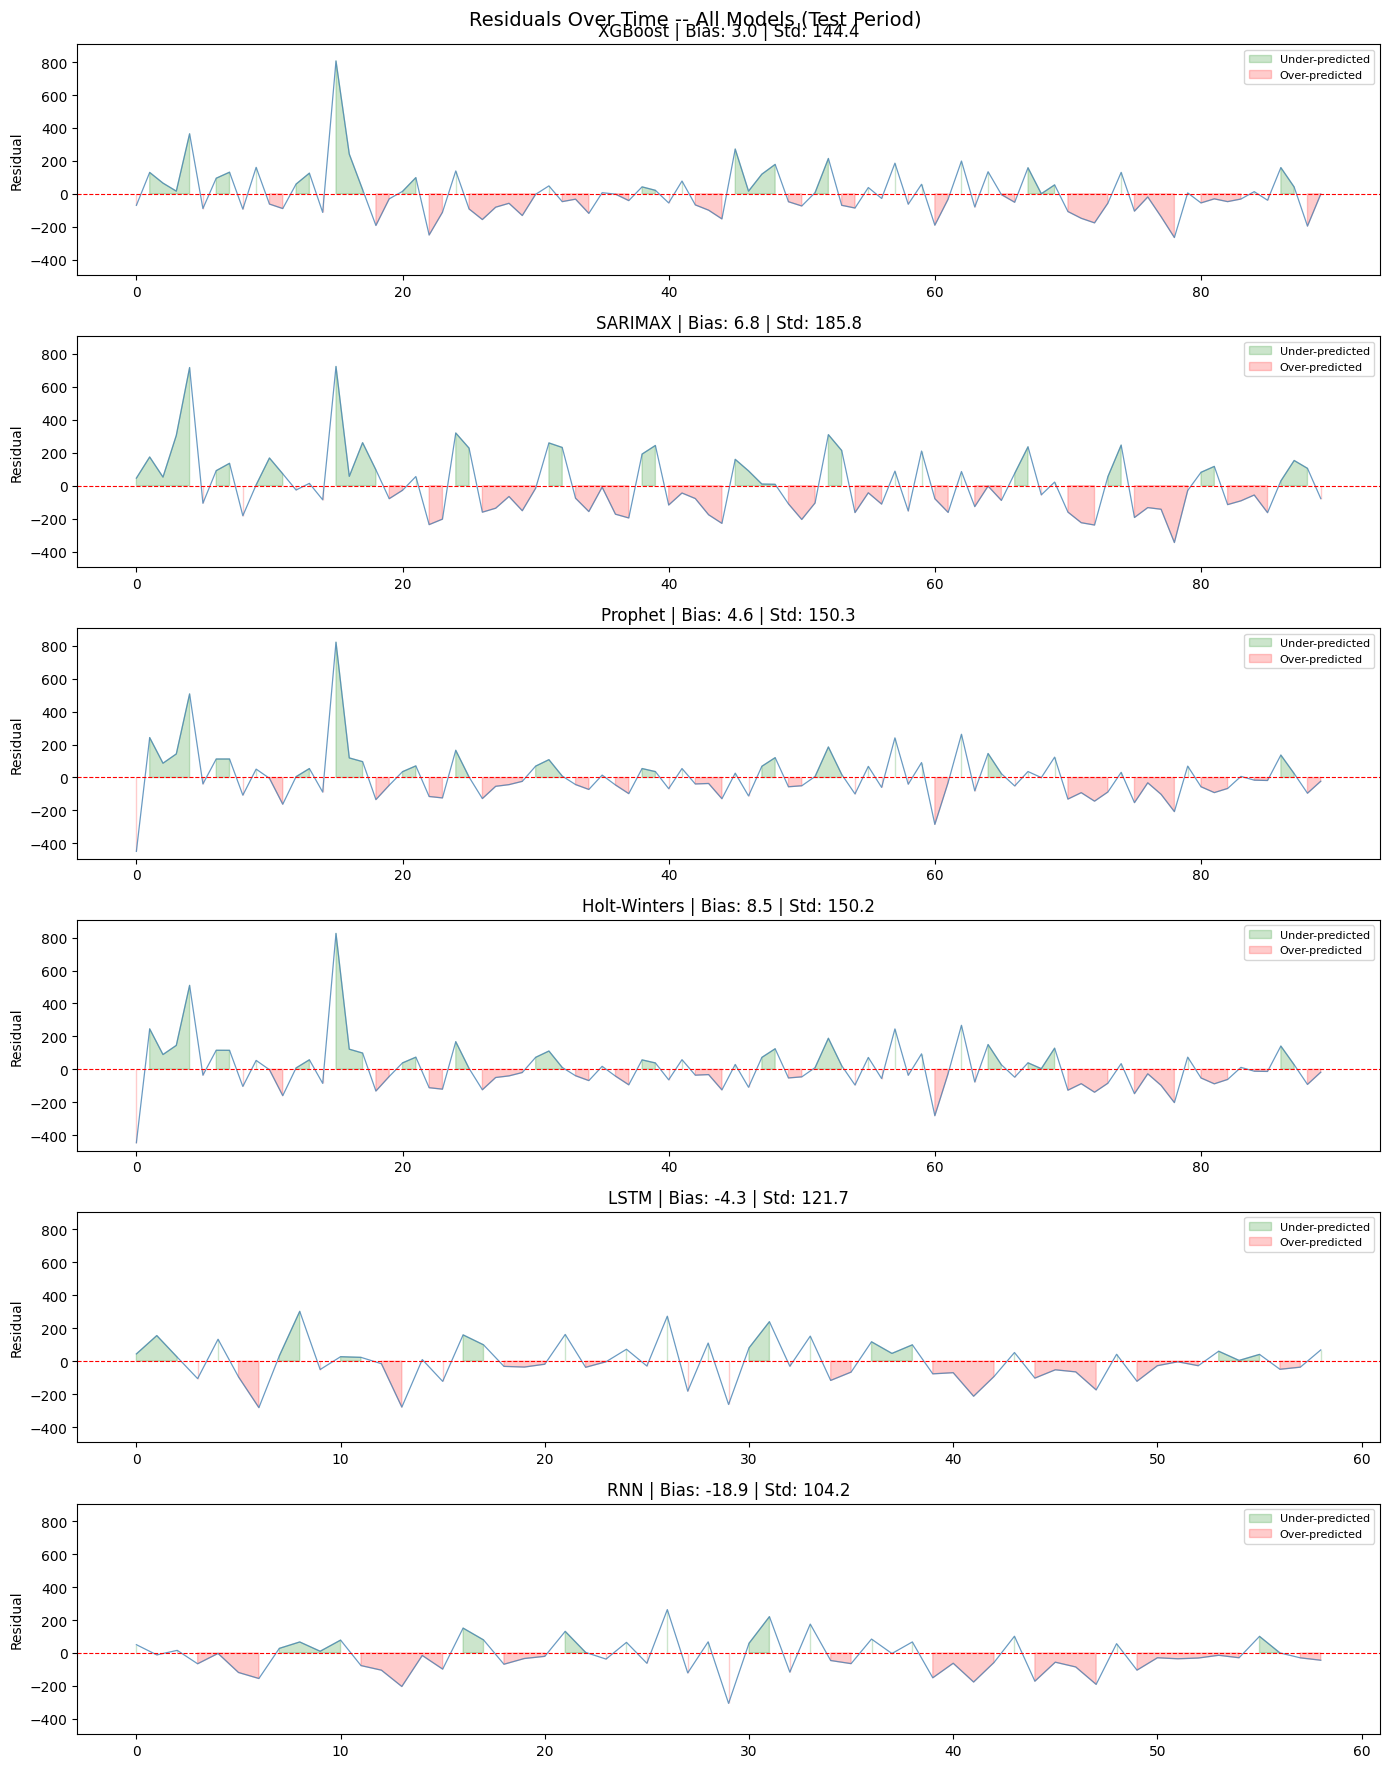

Saved: residuals_over_time.png


In [3]:
# Plot 1: Residuals Over Time
fig, axes = plt.subplots(len(all_models), 1, figsize=(14, 18), sharex=False)
fig.suptitle('Residuals Over Time -- All Models (Test Period)', fontsize=14)

for ax, (name, data) in zip(axes, all_models.items()):
    r = data['residual']
    # Set consistent y-axis range across all residual plots
    residual_min = min(data['residual'].min() for data in all_models.values())
    residual_max = max(data['residual'].max() for data in all_models.values())
    ax.plot(r, color='steelblue', linewidth=0.9, alpha=0.8)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
    ax.fill_between(range(len(r)), r, 0,
                    where=(r > 0), alpha=0.2, color='green', label='Under-predicted')
    ax.fill_between(range(len(r)), r, 0,
                    where=(r < 0), alpha=0.2, color='red', label='Over-predicted')
    ax.set_title(f'{name} | Bias: {r.mean():.1f} | Std: {r.std():.1f}')
    ax.set_ylabel('Residual')
    ax.set_ylim(residual_min * 1.1, residual_max * 1.1)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.MODELS_PATH, 'residuals_over_time.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residuals_over_time.png")

---
## S3 - Plot 2: Error Distribution Histograms

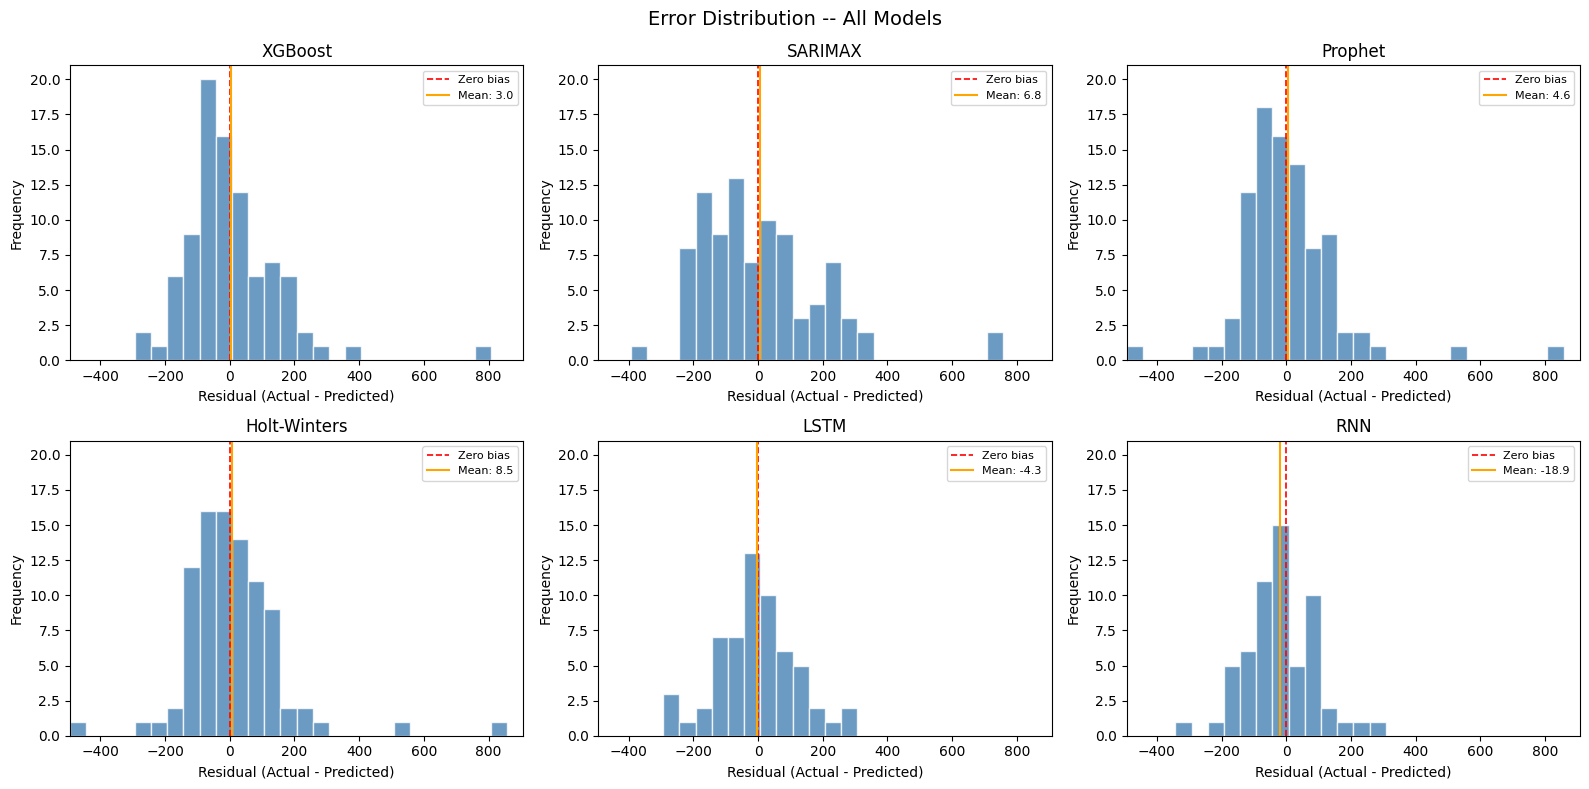

Saved: error_distributions.png


In [4]:
# Plot 2: Error Distribution Histograms
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Error Distribution -- All Models', fontsize=14)

for ax, (name, data) in zip(axes.flatten(), all_models.items()):
    r = data['residual']
    # Consistent axis ranges across all histograms
    err_min = min(data['residual'].min() for data in all_models.values())
    err_max = max(data['residual'].max() for data in all_models.values())
    global_freq_max = 21  # set after visually checking tallest bar across all panels
    ax.hist(r, bins=range(int(err_min*1.1), int(err_max*1.1), 50), color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero bias')
    ax.axvline(r.mean(), color='orange', linestyle='-', linewidth=1.5,
               label=f'Mean: {r.mean():.1f}')
    ax.set_title(name)
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Frequency')
    ax.set_ylim(0, global_freq_max)
    ax.set_xlim(err_min * 1.1, err_max * 1.1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.MODELS_PATH, 'error_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: error_distributions.png")

---
## S4 - Plot 3: Actual vs Predicted Scatter

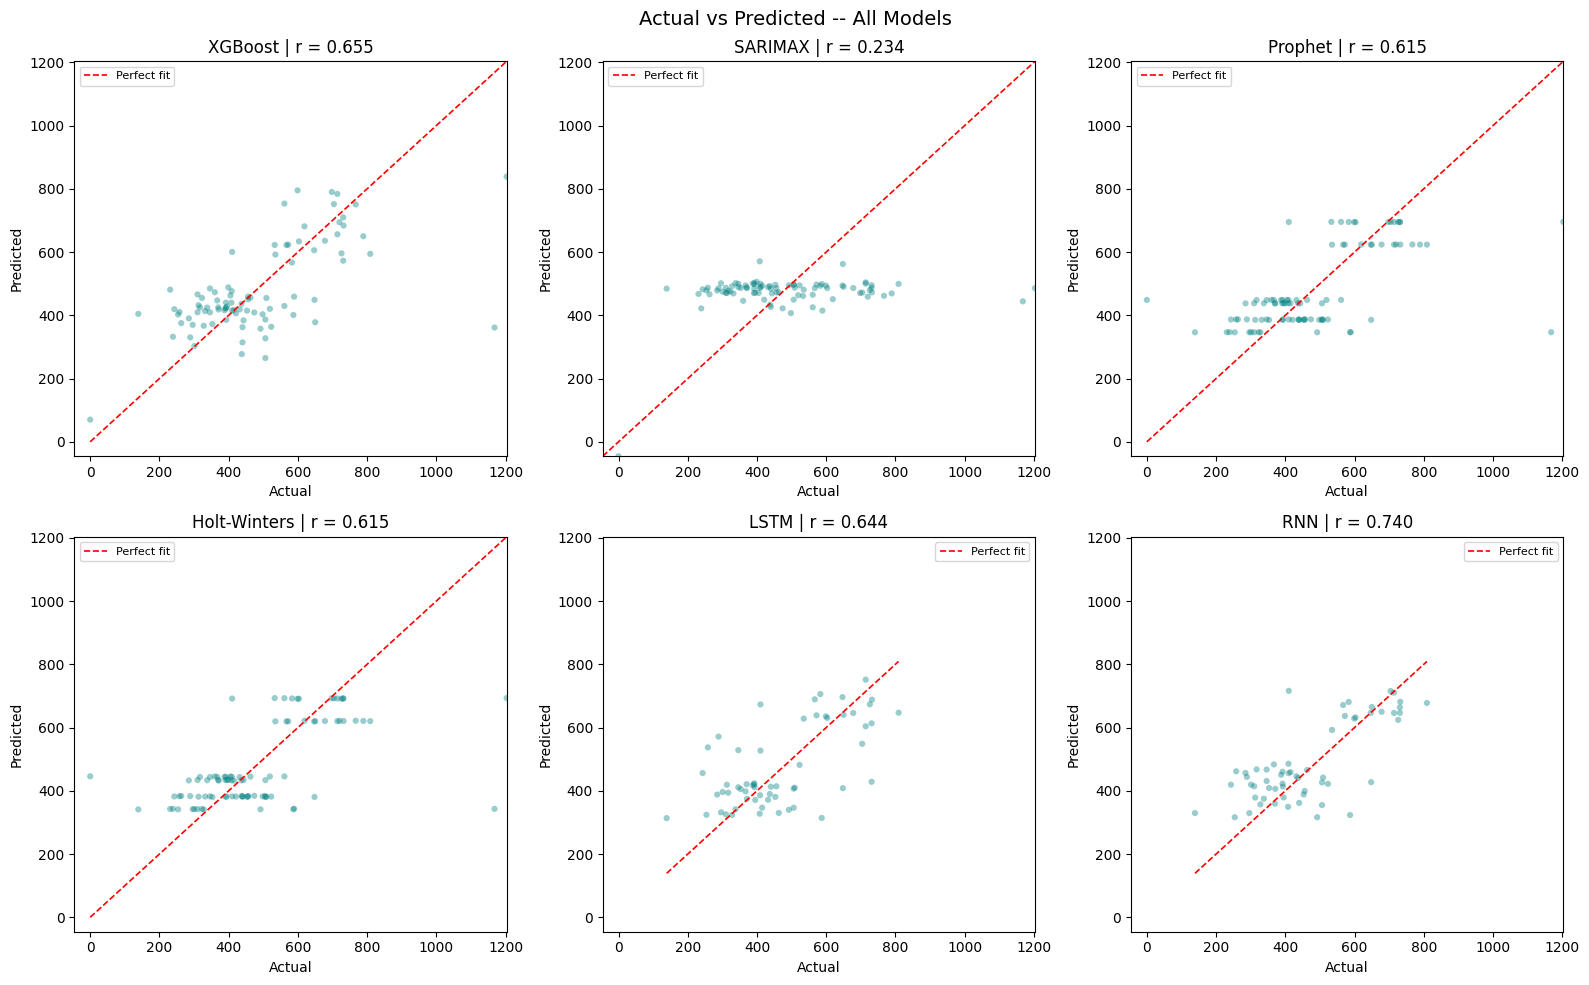

Saved: actual_vs_predicted.png


In [5]:
# Plot 3: Actual vs Predicted Scatter
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Actual vs Predicted -- All Models', fontsize=14)

for ax, (name, data) in zip(axes.flatten(), all_models.items()):
    actual = data['actual']
    pred   = data['predicted']
    global_min = min(min(d['actual'].min(), d['predicted'].min()) for d in all_models.values())
    global_max = max(max(d['actual'].max(), d['predicted'].max()) for d in all_models.values())
    ax.scatter(actual, pred, alpha=0.4, color='teal', s=20, edgecolors='none')
    min_val = min(actual.min(), pred.min())
    max_val = max(actual.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', 
            linewidth=1.2, label='Perfect fit')
    r = np.corrcoef(actual, pred)[0, 1]
    ax.set_title(f'{name} | r = {r:.3f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(global_min, global_max)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.MODELS_PATH, 'actual_vs_predicted.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted.png")

---
## S5 - Plot 4: ACF of Residuals

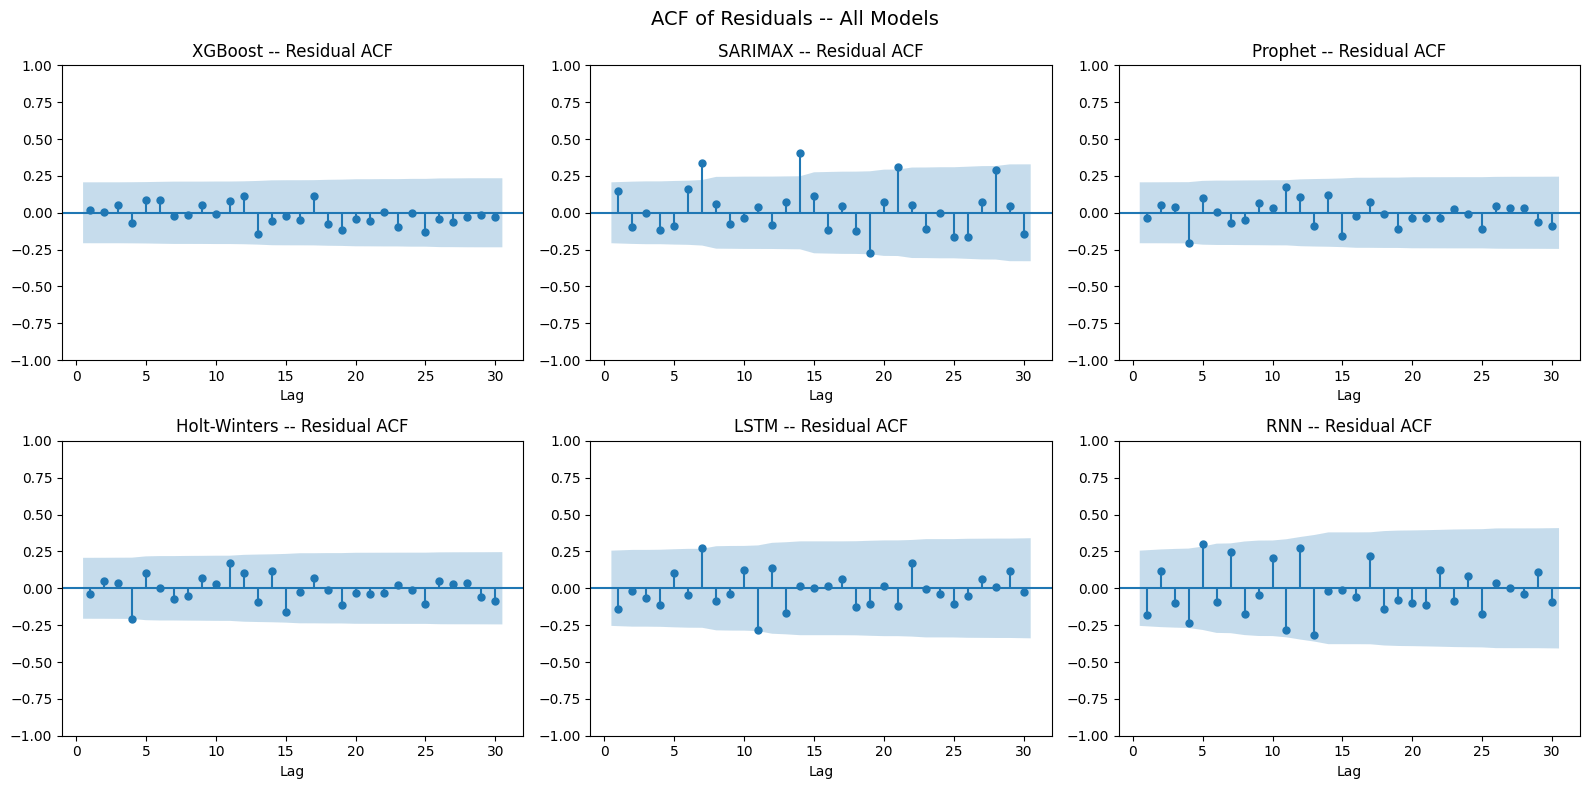

Saved: residuals_acf.png


In [6]:
# Plot 4: ACF of Residuals
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('ACF of Residuals -- All Models', fontsize=14)

for ax, (name, data) in zip(axes.flatten(), all_models.items()):
    plot_acf(data['residual'], lags=30, ax=ax, zero=False, alpha=0.05)
    ax.set_title(f'{name} -- Residual ACF')
    ax.set_xlabel('Lag')

plt.tight_layout()
plt.savefig(os.path.join(config.MODELS_PATH, 'residuals_acf.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residuals_acf.png")

---
## S7 - Actual vs Predicted Overlay (Best Model = RNN)

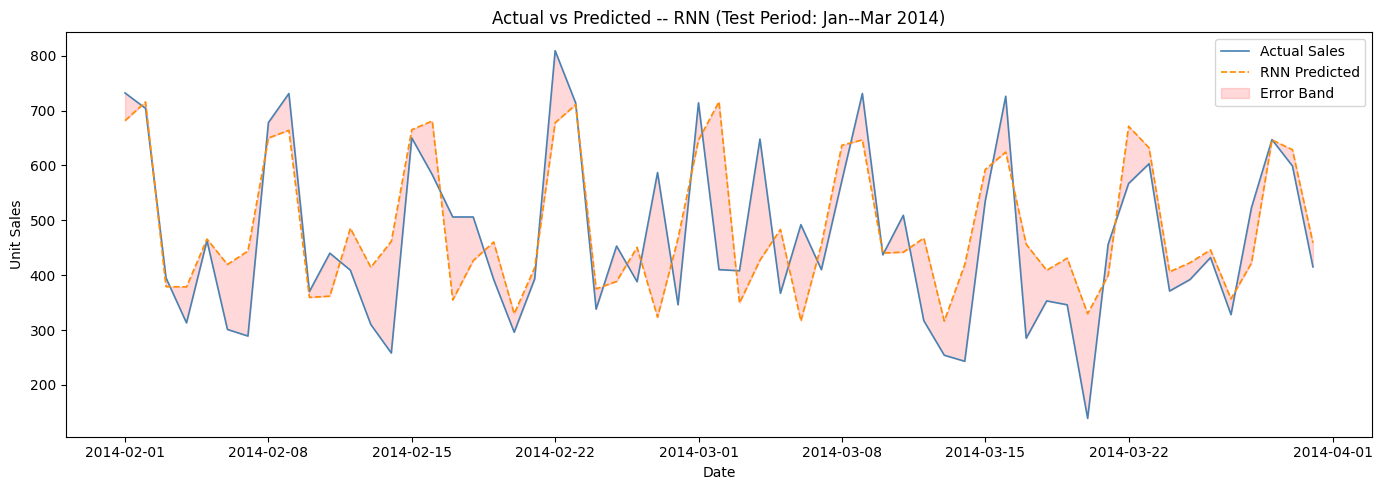

Saved: actual_vs_predicted_rnn.png


In [7]:
# Actual vs Predicted Overlay (Best Model = RNN)
rnn_data = all_models['RNN']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rnn_data['index'], rnn_data['actual'], 
        color='steelblue', linewidth=1.2, label='Actual Sales')
ax.plot(rnn_data['index'], rnn_data['predicted'], 
        color='darkorange', linewidth=1.2, linestyle='--', label='RNN Predicted')
ax.fill_between(rnn_data['index'],
                rnn_data['actual'], rnn_data['predicted'],
                alpha=0.15, color='red', label='Error Band')

ax.set_title('Actual vs Predicted -- RNN (Test Period: Jan--Mar 2014)')
ax.set_xlabel('Date')
ax.set_ylabel('Unit Sales')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.MODELS_PATH, 'actual_vs_predicted_rnn.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted_rnn.png")

---
## S6 - Summary Table

In [8]:
# Summary Table
print(f"\n{'='*65}")
print(f"{'Model':<15} {'RMSE':>8} {'MAE':>8} {'Bias':>8} {'Std Err':>10}")
print(f"{'='*65}")

for name, data in all_models.items():
    r = data['residual']
    rmse = np.sqrt(np.mean(r**2))
    mae  = np.mean(np.abs(r))
    bias = r.mean()
    std  = r.std()
    print(f"{name:<15} {rmse:>8.2f} {mae:>8.2f} {bias:>8.2f} {std:>10.2f}")

print(f"{'='*65}")


Model               RMSE      MAE     Bias    Std Err
XGBoost           144.45   100.50     2.97     144.42
SARIMAX           185.90   142.98     6.77     185.77
Prophet           150.33    98.79     4.60     150.26
Holt-Winters      150.41    98.43     8.46     150.17
LSTM              121.77    93.51    -4.30     121.70
RNN               105.95    82.60   -18.94     104.25
